# 🏠 Predicting House Prices with Linear Regression
### Ames Housing Dataset — End-to-End ML Pipeline

This notebook walks through every step of a regression project:
- **Exploratory Data Analysis (EDA)** — understanding the data before touching a model
- **Feature Engineering** — thoughtful selection, cleaning, and encoding
- **Model Training** — Linear Regression (OLS) as the baseline
- **Evaluation** — MSE, RMSE, R², residual diagnostics
- **Bonus** — Ridge & Lasso regularisation comparison

---
**Dataset:** Ames Housing (`AmesHousing.csv`) — 2,930 residential sales in Ames, Iowa (2006–2010)  
**Target:** `SalePrice` (USD)

## 0 · Imports & Global Settings

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
TARGET = "SalePrice"
print("✅ All packages imported successfully.")

✅ All packages imported successfully.


## 1 · Load Dataset & First Look

We load the raw CSV and take a quick pulse-check on size, types, and a sample of rows.

In [2]:
df = pd.read_csv("AmesHousing.csv")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)

Shape: 2,930 rows × 82 columns
Memory usage: 7.3 MB


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


In [3]:
# Quick dtype summary
dtype_counts = df.dtypes.value_counts().rename_axis("dtype").reset_index(name="count")
print("Column type breakdown:")
print(dtype_counts.to_string(index=False))

Column type breakdown:
  dtype  count
    str     43
  int64     28
float64     11


## 2 · Null Check & Descriptive Statistics

Before any modelling, we need to understand the extent and nature of missing data.

In [4]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df = (
    pd.DataFrame({"Missing Count": null_counts, "Missing %": null_pct})
    .query("`Missing Count` > 0")
    .sort_values("Missing %", ascending=False)
)
print(f"{len(null_df)} columns have missing values:\n")
print(null_df.to_string())

27 columns have missing values:

                Missing Count  Missing %
Pool QC                  2917      99.56
Misc Feature             2824      96.38
Alley                    2732      93.24
Fence                    2358      80.48
Mas Vnr Type             1775      60.58
Fireplace Qu             1422      48.53
Lot Frontage              490      16.72
Garage Qual               159       5.43
Garage Cond               159       5.43
Garage Yr Blt             159       5.43
Garage Finish             159       5.43
Garage Type               157       5.36
Bsmt Exposure              83       2.83
BsmtFin Type 2             81       2.76
Bsmt Cond                  80       2.73
Bsmt Qual                  80       2.73
BsmtFin Type 1             80       2.73
Mas Vnr Area               23       0.78
Bsmt Full Bath              2       0.07
Bsmt Half Bath              2       0.07
BsmtFin SF 1                1       0.03
BsmtFin SF 2                1       0.03
Electrical              

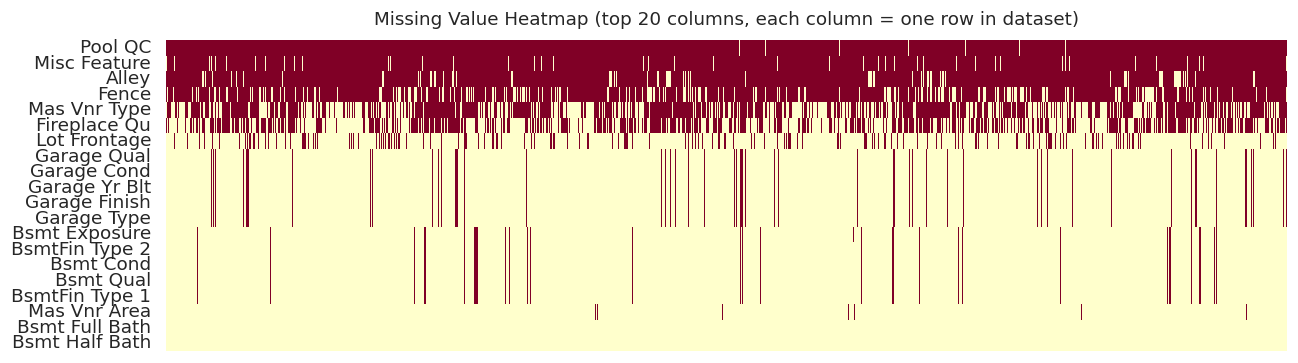

In [5]:
# Visual: missing data heatmap (top 20 columns by missingness)
top_missing = null_df.head(20).index.tolist()

fig, ax = plt.subplots(figsize=(12, 3.5))
miss_matrix = df[top_missing].isnull().astype(int).T
sns.heatmap(miss_matrix, cmap="YlOrRd", cbar=False, linewidths=0,
            yticklabels=top_missing, xticklabels=False, ax=ax)
ax.set_title("Missing Value Heatmap (top 20 columns, each column = one row in dataset)",
             fontsize=12, pad=10)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [6]:
# Descriptive statistics for numeric columns
df.describe().round(2)

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00,2.930000e+03,2930.00,2440.00,2930.00,2930.00,2930.00,2930.00,2930.00,2907.00,...,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00
mean,1465.50,7.144645e+08,57.39,69.22,10147.92,6.09,5.56,1971.36,1984.27,101.90,...,93.75,47.53,23.01,2.59,16.00,2.24,50.64,6.22,2007.79,180796.06
std,845.96,1.887308e+08,42.64,23.37,7880.02,1.41,1.11,30.25,20.86,179.11,...,126.36,67.48,64.14,25.14,56.09,35.60,566.34,2.71,1.32,79886.69
min,1.00,5.263011e+08,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,12789.00
25%,733.25,5.284770e+08,20.00,58.00,7440.25,5.00,5.00,1954.00,1965.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,2007.00,129500.00
50%,1465.50,5.354536e+08,50.00,68.00,9436.50,6.00,5.00,1973.00,1993.00,0.00,...,0.00,27.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,160000.00
75%,2197.75,9.071811e+08,70.00,80.00,11555.25,7.00,6.00,2001.00,2004.00,164.00,...,168.00,70.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,213500.00
max,2930.00,1.007100e+09,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,...,1424.00,742.00,1012.00,508.00,576.00,800.00,17000.00,12.00,2010.00,755000.00


## 3 · Distribution of the Target Variable (SalePrice)

Linear regression assumes residuals are normally distributed; a skewed target often
benefits from a **log transformation** so let's inspect both.

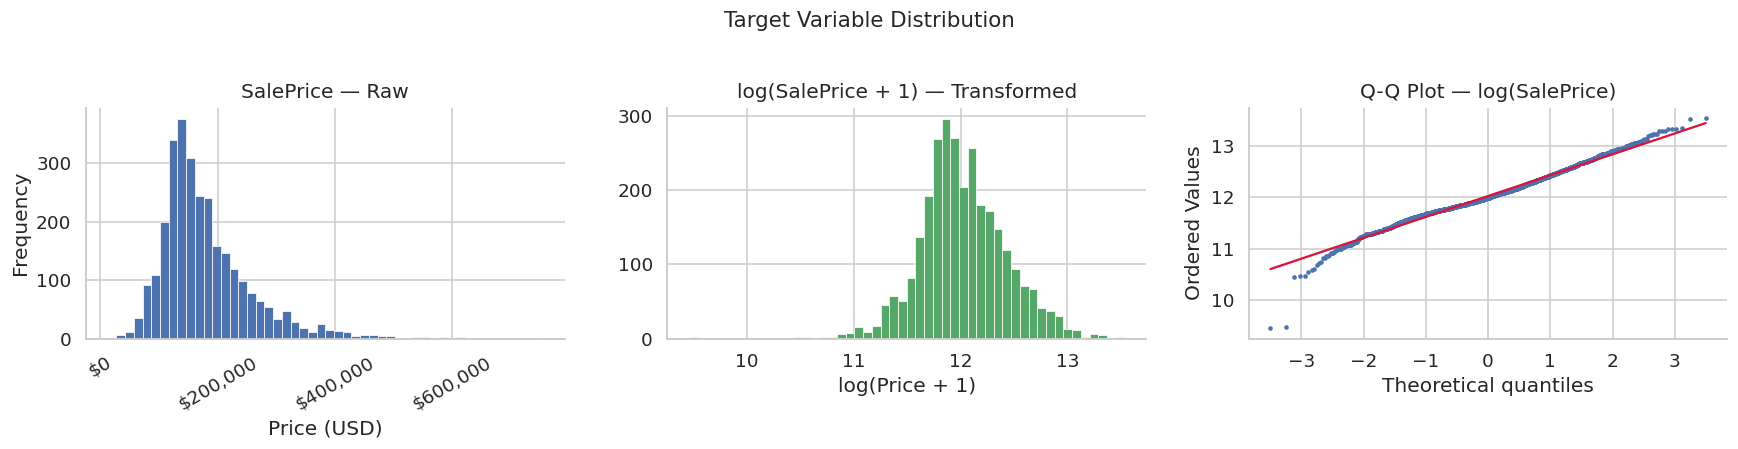

Skewness — Raw: 1.744  |  Log-transformed: -0.015
ℹ️  We will model on log(SalePrice) and exponentiate predictions back.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw price histogram
axes[0].hist(df[TARGET], bins=50, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0].set_title("SalePrice — Raw")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for tick in axes[0].get_xticklabels():
    tick.set_rotation(30)

# Log-transformed histogram
log_price = np.log1p(df[TARGET])
axes[1].hist(log_price, bins=50, color="#55A868", edgecolor="white", linewidth=0.5)
axes[1].set_title("log(SalePrice + 1) — Transformed")
axes[1].set_xlabel("log(Price + 1)")

# Q-Q plot of log price
stats.probplot(log_price, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot — log(SalePrice)")
axes[2].get_lines()[0].set(color="#4C72B0", markersize=2)
axes[2].get_lines()[1].set(color="crimson", lw=1.5)

plt.suptitle("Target Variable Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

skew_raw = df[TARGET].skew()
skew_log = log_price.skew()
print(f"Skewness — Raw: {skew_raw:.3f}  |  Log-transformed: {skew_log:.3f}")
print("ℹ️  We will model on log(SalePrice) and exponentiate predictions back.")

## 4 · Feature Selection — Reasoning & Choices

### Why not just use all 81 columns?

Several columns should be excluded or handled carefully:

| Column | Reason to Drop / Handle |
|--------|--------------------------|
| `Order`, `PID` | Administrative IDs — no predictive signal |
| `Pool QC`, `Misc Feature`, `Alley`, `Fence` | >80 % missing; NaN itself is the signal (no pool, no alley, etc.) |
| `Mas Vnr Type` | >60 % missing; correlated with `Mas Vnr Area` which we keep |
| `Fireplace Qu` | ~48 % missing; `Fireplaces` count already captures this |
| `Garage Yr Blt` | ~5 % missing, correlated with `Year Built` |
| `Lot Frontage` | ~17 % missing; fill with neighbourhood median |

### Selected Feature Groups

- **Size metrics** — `Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`, `Garage Area`, `Lot Area`
- **Quality scores** — `Overall Qual`, `Overall Cond`, `Exter Qual`, `Kitchen Qual`, `Bsmt Qual`
- **Room counts** — `TotRms AbvGrd`, `Full Bath`, `Bedroom AbvGr`, `Garage Cars`, `Fireplaces`
- **Age / time** — `Year Built`, `Year Remod/Add` (used to derive `House Age` and `Remod Age`)
- **Location** — `Neighborhood` (one-hot encoded)
- **Other categorical** — `MS Zoning`, `Bldg Type`, `House Style`, `Central Air`, `Sale Condition`

> **Key insight:** `Overall Qual` alone has a Pearson r ≈ 0.80 with SalePrice —
> making it the single strongest predictor in this dataset.

## 5 · Feature Engineering, Missing Value Handling & Encoding

In [8]:
# ── 5a. Drop columns with very high missingness or no predictive value ─────
DROP_COLS = [
    "Order", "PID",                             # IDs
    "Pool QC", "Misc Feature", "Alley", "Fence",# >80% missing
    "Mas Vnr Type",                             # >60% missing; Area is enough
    "Fireplace Qu",                             # 48% missing; Fireplaces count kept
    "Garage Yr Blt",                            # correlated with Year Built
    "Condition 2", "Roof Matl",                 # near-zero variance
    "Heating", "Utilities",                     # near-zero variance
    "Low Qual Fin SF", "3Ssn Porch",            # very sparse
    "Pool Area", "Misc Val",                    # very sparse
    "BsmtFin SF 2", "BsmtFin Type 2",          # redundant
]

df2 = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore").copy()
print(f"Columns after dropping: {df2.shape[1]} (was {df.shape[1]})")

Columns after dropping: 63 (was 82)


In [ ]:
df2["LogPrice"] = np.log1p(df2[TARGET])

df2["House Age"]      = df2["Yr Sold"] - df2["Year Built"]
df2["Remod Age"]      = df2["Yr Sold"] - df2["Year Remod/Add"]
df2["Total Bath"]     = df2["Full Bath"] + 0.5 * df2["Half Bath"] +                         df2["Bsmt Full Bath"].fillna(0) + 0.5 * df2["Bsmt Half Bath"].fillna(0)
df2["Total SF"]       = df2["Gr Liv Area"] + df2["Total Bsmt SF"].fillna(0)


df2["Lot Frontage"] = df2.groupby("Neighborhood")["Lot Frontage"]                         .transform(lambda x: x.fillna(x.median()))


num_cols = df2.select_dtypes(include="number").columns
df2[num_cols] = df2[num_cols].fillna(0)


quality_fill = {
    "Garage Type": "No Garage", "Garage Finish": "No Garage",
    "Garage Qual": "No Garage", "Garage Cond": "No Garage",
    "Bsmt Qual": "No Bsmt", "Bsmt Cond": "No Bsmt",
    "Bsmt Exposure": "No Bsmt", "BsmtFin Type 1": "No Bsmt",
}
for col, fill in quality_fill.items():
    if col in df2.columns:
        df2[col] = df2[col].fillna(fill)

cat_cols = df2.select_dtypes(include="object").columns
df2[cat_cols] = df2[cat_cols].fillna("Unknown")

print(f"Remaining nulls after cleaning: {df2.isnull().sum().sum()}")
print(f"Dataset shape: {df2.shape}")

Remaining nulls after cleaning: 0
Dataset shape: (2930, 68)


In [ ]:

NUMERIC_FEATURES = [
    "Gr Liv Area", "Total Bsmt SF", "1st Flr SF", "2nd Flr SF",
    "Garage Area", "Lot Area", "Lot Frontage",
    "Overall Qual", "Overall Cond",
    "TotRms AbvGrd", "Total Bath", "Bedroom AbvGr", "Garage Cars",
    "Fireplaces", "Wood Deck SF", "Open Porch SF", "Screen Porch",
    "Mas Vnr Area", "Enclosed Porch",
    "House Age", "Remod Age", "Total SF",
    "Mo Sold",
]

CAT_FEATURES = [
    "Neighborhood", "MS Zoning", "Bldg Type", "House Style",
    "Exter Qual", "Kitchen Qual", "Bsmt Qual",
    "Central Air", "Heating QC", "Electrical",
    "Garage Type", "Paved Drive",
    "Foundation", "Roof Style",
    "Sale Type", "Sale Condition",
]


NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df2.columns]
CAT_FEATURES     = [c for c in CAT_FEATURES     if c in df2.columns]

print(f"Numeric features : {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CAT_FEATURES)}")

Numeric features : 23
Categorical features: 16


In [ ]:
X_num = df2[NUMERIC_FEATURES].copy()
X_cat = pd.get_dummies(df2[CAT_FEATURES], drop_first=True, dtype=float)

X = pd.concat([X_num, X_cat], axis=1)
y = df2["LogPrice"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape : {y.shape}")

Feature matrix shape: (2930, 121)
Target vector shape : (2930,)


## 6 · Correlation Heatmap — Numeric Features vs SalePrice

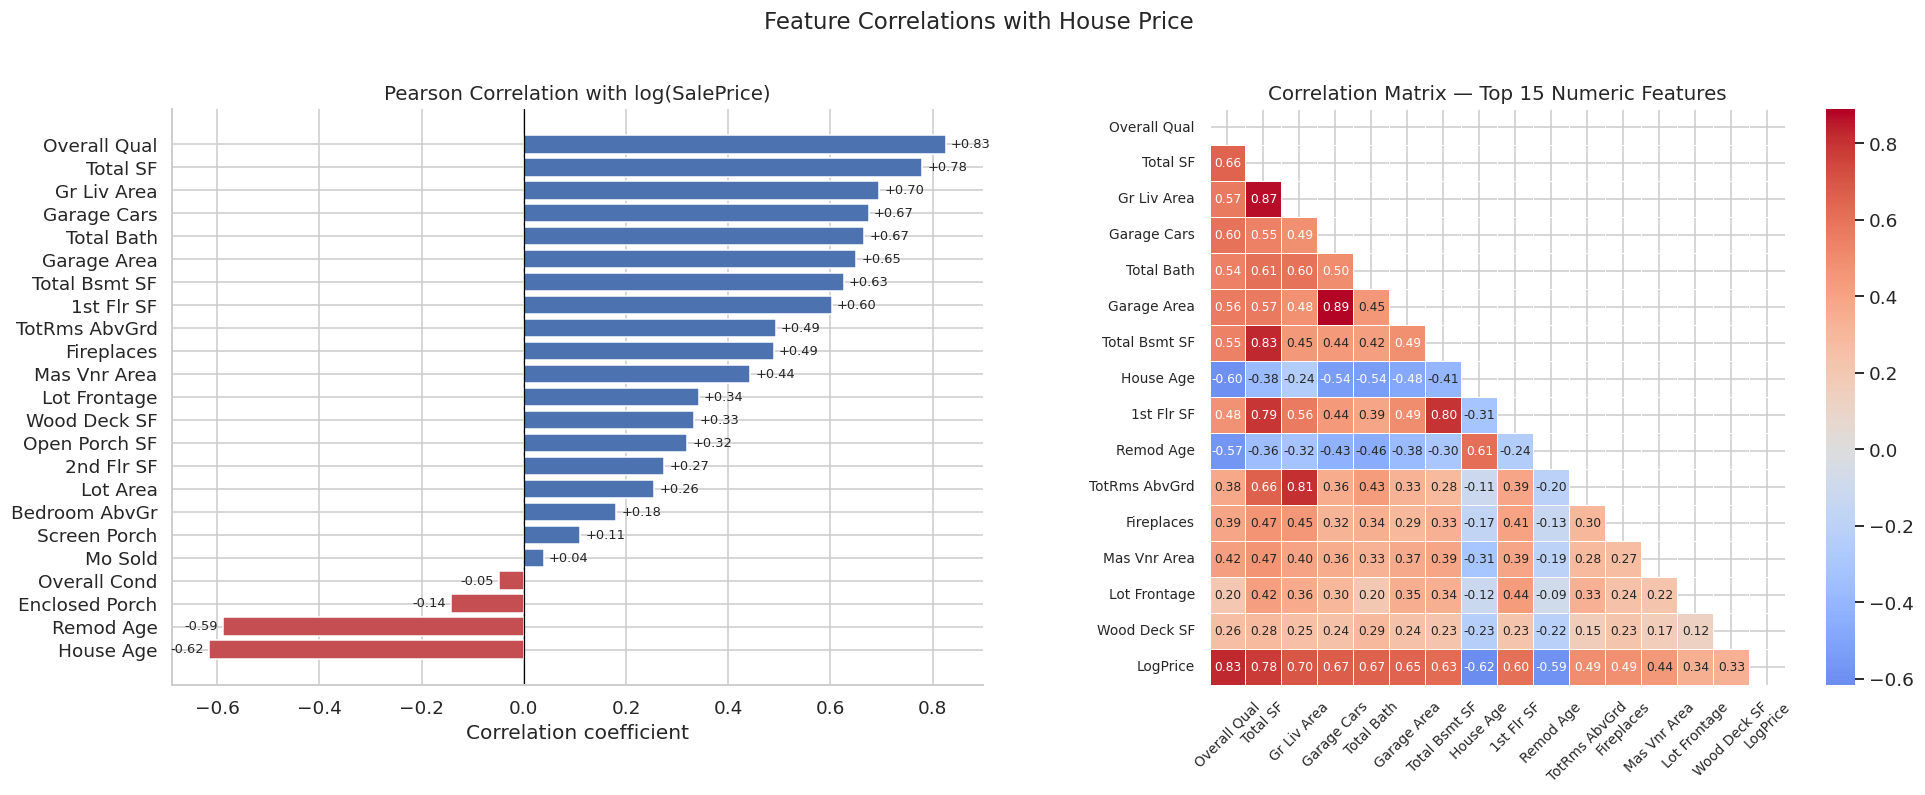

Top 5 positive correlators:
Overall Qual    0.825645
Total SF        0.779437
Gr Liv Area     0.695863
Garage Cars     0.674878
Total Bath      0.666187

Top 5 negative correlators:
Mo Sold           0.038960
Overall Cond     -0.048294
Enclosed Porch   -0.142486
Remod Age        -0.588285
House Age        -0.615990


In [ ]:

corr_series = (
    pd.concat([X_num, y], axis=1)
    .corr()["LogPrice"]
    .drop("LogPrice")
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in corr_series.values]
axes[0].barh(corr_series.index[::-1], corr_series.values[::-1], color=colors[::-1], edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Pearson Correlation with log(SalePrice)", fontsize=13)
axes[0].set_xlabel("Correlation coefficient")
for i, (v, name) in enumerate(zip(corr_series.values[::-1], corr_series.index[::-1])):
    axes[0].text(v + (0.01 if v >= 0 else -0.01), i,
                 f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=8.5)

top15 = corr_series.abs().sort_values(ascending=False).head(15).index.tolist()
corr_matrix = pd.concat([X_num[top15], y], axis=1).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, ax=axes[1],
            annot_kws={"size": 8})
axes[1].set_title("Correlation Matrix — Top 15 Numeric Features", fontsize=13)
axes[1].tick_params(axis="x", rotation=45, labelsize=9)
axes[1].tick_params(axis="y", rotation=0, labelsize=9)

plt.suptitle("Feature Correlations with House Price", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("Top 5 positive correlators:")
print(corr_series.head(5).to_string())
print("\nTop 5 negative correlators:")
print(corr_series.tail(5).to_string())

### 6b · Scatter Plots — Top Predictors vs SalePrice

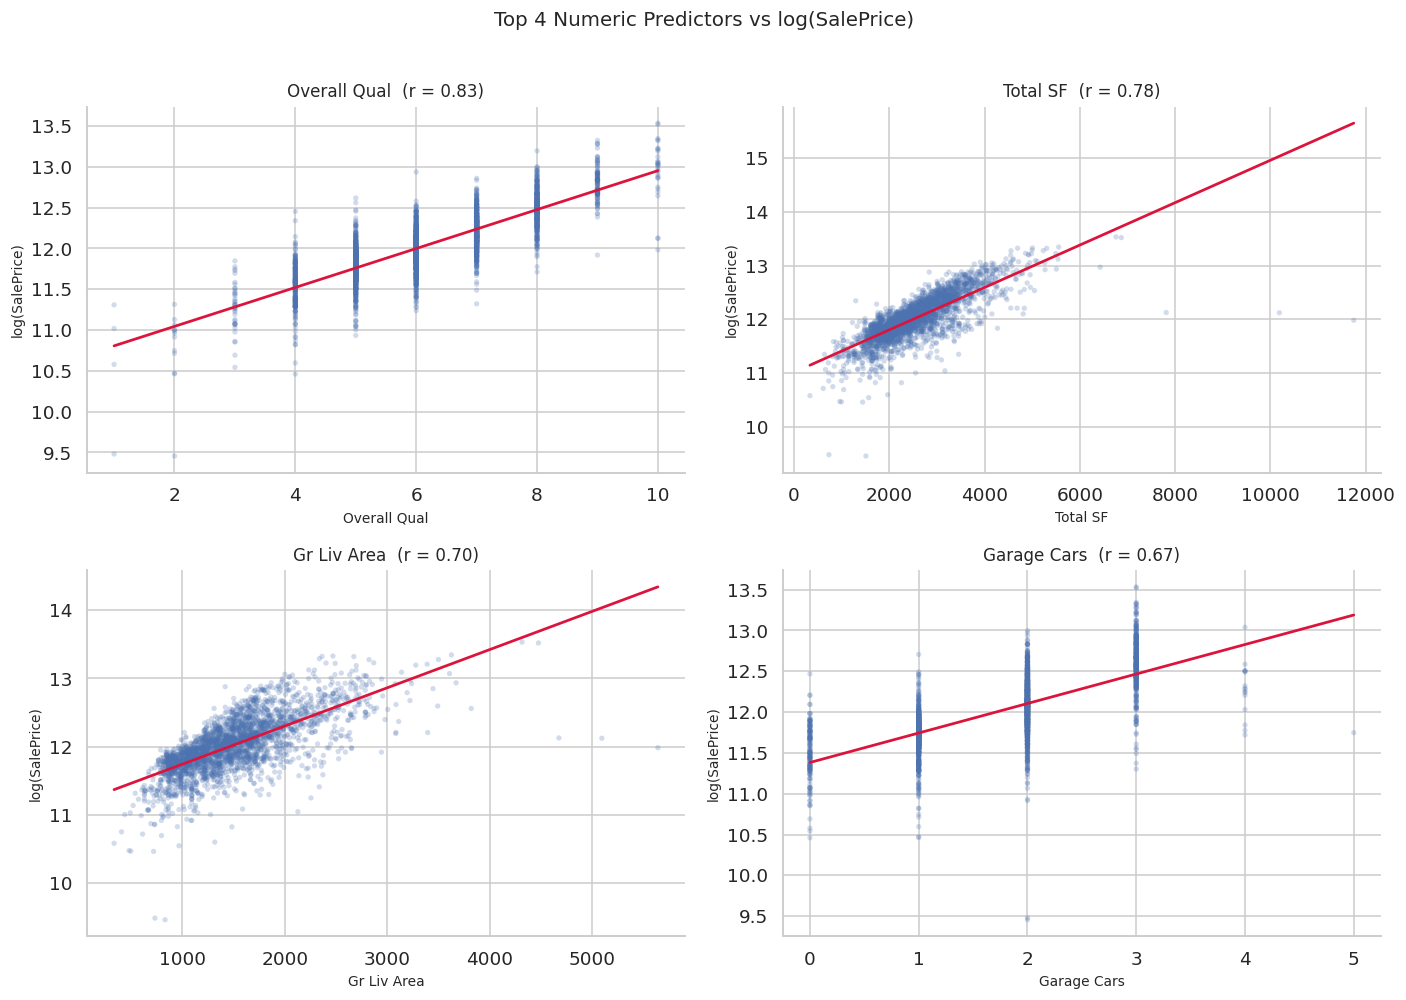

In [13]:
top4 = corr_series.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, top4):
    ax.scatter(df2[col], df2["LogPrice"], alpha=0.25, s=12, color="#4C72B0", edgecolors="none")
    # regression line
    m, b = np.polyfit(df2[col], df2["LogPrice"], 1)
    xs = np.linspace(df2[col].min(), df2[col].max(), 200)
    ax.plot(xs, m*xs + b, color="crimson", lw=1.8)
    r = df2[[col, "LogPrice"]].corr().iloc[0, 1]
    ax.set_title(f"{col}  (r = {r:.2f})", fontsize=11)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("log(SalePrice)", fontsize=9)

plt.suptitle("Top 4 Numeric Predictors vs log(SalePrice)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7 · Train / Test Split (80 / 20)

Training set : 2,344 rows (80%)
Test set     : 586 rows (20%)
Features     : 121


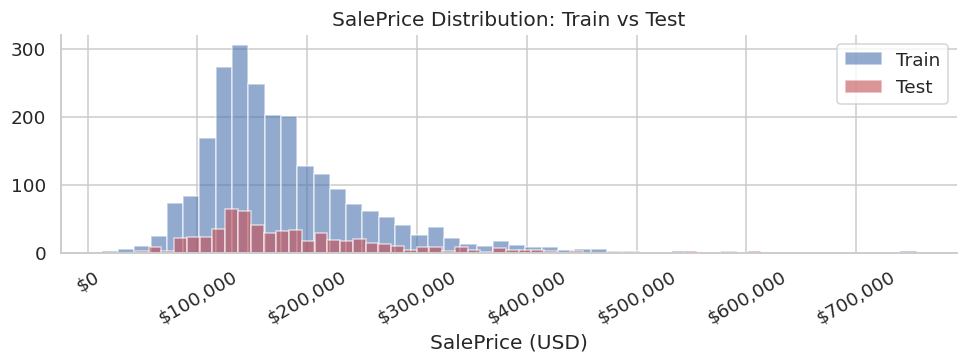

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f"Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features     : {X.shape[1]:,}")


fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(np.expm1(y_train), bins=50, alpha=0.6, label="Train", color="#4C72B0", edgecolor="white")
ax.hist(np.expm1(y_test),  bins=50, alpha=0.6, label="Test",  color="#C44E52", edgecolor="white")
ax.set_xlabel("SalePrice (USD)")
ax.set_title("SalePrice Distribution: Train vs Test")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

## 8 · Train Linear Regression Model

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_log  = lr.predict(X_test)


y_pred_raw  = np.expm1(y_pred_log)
y_test_raw  = np.expm1(y_test)

print("✅ Linear Regression trained.")
print(f"   Intercept : {lr.intercept_:.4f}")
print(f"   Coefficients: {len(lr.coef_)}")

✅ Linear Regression trained.
   Intercept : 10.2685
   Coefficients: 121


## 9 · Model Evaluation — MSE, RMSE, R²

In [ ]:
def evaluate(name, y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
   
    r2_log = r2_score(y_true_log, y_pred_log)
    return {"Model": name, "MSE ($²)": f"{mse:,.0f}", "RMSE ($)": f"{rmse:,.0f}",
            "R² (price)": f"{r2:.4f}", "R² (log)": f"{r2_log:.4f}"}

results = []
results.append(evaluate("Linear Regression", y_test, y_pred_log))

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

mse_val  = mean_squared_error(y_test_raw, y_pred_raw)
rmse_val = np.sqrt(mse_val)
r2_val   = r2_score(y_test_raw, y_pred_raw)

print("\n=== Linear Regression - Test Metrics ===")
print(f"  MSE  : ${mse_val:>15,.0f}")
print(f"  RMSE : ${rmse_val:>15,.0f}")
print(f"  R2   :  {r2_val:.4f}")
print("=========================================")
print(f"  Model explains ~{r2_val*100:.0f}% of price variance.")
print(f"  Typical prediction error: ${rmse_val:,.0f}")

            Model    MSE ($²) RMSE ($) R² (price) R² (log)
Linear Regression 978,043,663   31,274     0.8780   0.9191

=== Linear Regression - Test Metrics ===
  MSE  : $    978,043,663
  RMSE : $         31,274
  R2   :  0.8780
  Model explains ~88% of price variance.
  Typical prediction error: $31,274


## 10 · Scatter Plot: Actual vs Predicted Prices

A perfect model would produce points on the diagonal (y = x line). Deviations show
where the model over- or under-predicts.

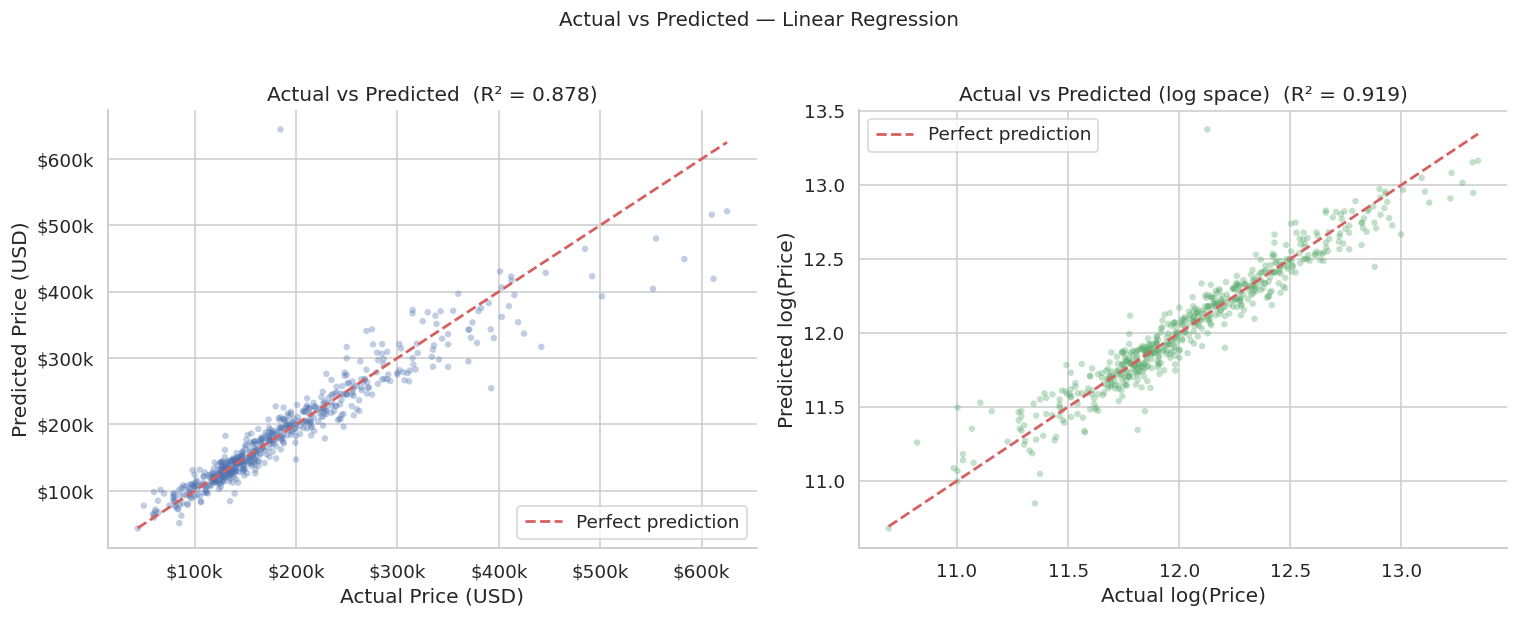

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))


ax = axes[0]
mn, mx = y_test_raw.min(), y_test_raw.max()
ax.scatter(y_test_raw, y_pred_raw, alpha=0.35, s=18, color="#4C72B0", edgecolors="none")
ax.plot([mn, mx], [mn, mx], "r--", lw=1.8, label="Perfect prediction")
ax.set_xlabel("Actual Price (USD)")
ax.set_ylabel("Predicted Price (USD)")
ax.set_title(f"Actual vs Predicted  (R² = {r2_val:.3f})")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax.legend()


ax2 = axes[1]
mn2, mx2 = y_test.min(), y_test.max()
ax2.scatter(y_test, y_pred_log, alpha=0.35, s=18, color="#55A868", edgecolors="none")
ax2.plot([mn2, mx2], [mn2, mx2], "r--", lw=1.8, label="Perfect prediction")
r2_log = r2_score(y_test, y_pred_log)
ax2.set_xlabel("Actual log(Price)")
ax2.set_ylabel("Predicted log(Price)")
ax2.set_title(f"Actual vs Predicted (log space)  (R² = {r2_log:.3f})")
ax2.legend()

plt.suptitle("Actual vs Predicted — Linear Regression", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11 · Residual Diagnostics

Residuals should be:
- **Randomly scattered** around zero (no systematic pattern → unbiased model)
- **Approximately normally distributed** (validates OLS assumptions)
- **Homoscedastic** (constant variance across predicted values)

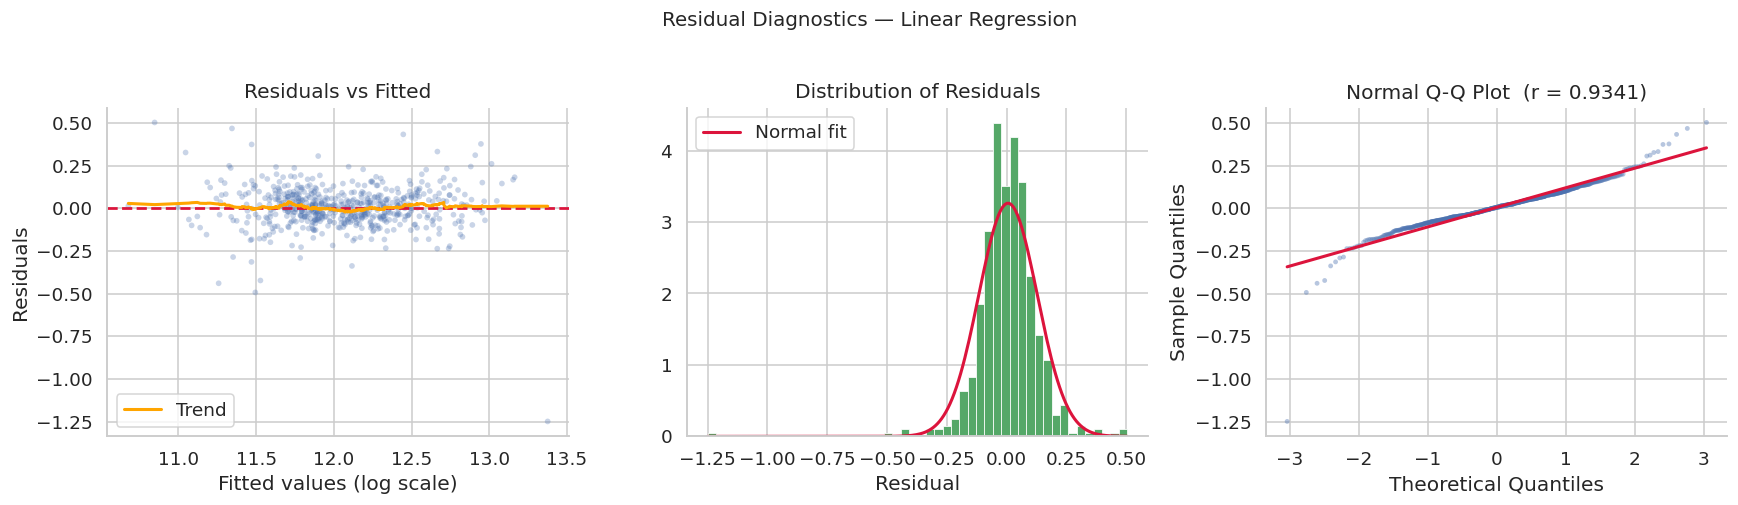

Residual stats — Mean: 0.00569 | Std: 0.1222 | Skewness: -1.704


In [ ]:
residuals = y_test.values - y_pred_log   # residuals in log space

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.scatter(y_pred_log, residuals, alpha=0.30, s=14, color="#4C72B0", edgecolors="none")
ax.axhline(0, color="crimson", lw=1.8, linestyle="--")
# LOWESS smoother trend
from scipy.ndimage import uniform_filter1d
order = np.argsort(y_pred_log)
trend = uniform_filter1d(residuals[order], size=80)
ax.plot(y_pred_log[order], trend, color="orange", lw=2, label="Trend")
ax.set_xlabel("Fitted values (log scale)")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")
ax.legend()

ax2 = axes[1]
ax2.hist(residuals, bins=50, color="#55A868", edgecolor="white", linewidth=0.5, density=True)
# Overlay normal curve
xn = np.linspace(residuals.min(), residuals.max(), 200)
ax2.plot(xn, stats.norm.pdf(xn, residuals.mean(), residuals.std()),
         color="crimson", lw=2, label="Normal fit")
ax2.set_xlabel("Residual")
ax2.set_title("Distribution of Residuals")
ax2.legend()

ax3 = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax3.scatter(osm, osr, s=10, alpha=0.40, color="#4C72B0", edgecolors="none")
ax3.plot(osm, slope * np.array(osm) + intercept, color="crimson", lw=2)
ax3.set_xlabel("Theoretical Quantiles")
ax3.set_ylabel("Sample Quantiles")
ax3.set_title(f"Normal Q-Q Plot  (r = {r:.4f})")

plt.suptitle("Residual Diagnostics — Linear Regression", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Residual stats — Mean: {residuals.mean():.5f} | Std: {residuals.std():.4f} "
      f"| Skewness: {pd.Series(residuals).skew():.3f}")

## 12 · Coefficient Analysis

Which features push house prices **up** or **down** the most?

> Note: Because we're working in **log space**, a coefficient of 0.1 means
> roughly a **10% increase** in SalePrice for a one-unit change in that feature
> (holding others constant).

In [19]:
coef_df = (
    pd.DataFrame({"Feature": X.columns, "Coefficient": lr.coef_})
    .sort_values("Coefficient", key=abs, ascending=False)
    .reset_index(drop=True)
)

print("Top 20 most impactful features:\n")
print(coef_df.head(20).to_string(index=False))

Top 20 most impactful features:

               Feature  Coefficient
  Neighborhood_GrnHill     0.577189
          MS Zoning_RH     0.562779
          MS Zoning_FV     0.542330
          MS Zoning_RL     0.530362
          MS Zoning_RM     0.501139
     MS Zoning_I (all)     0.500314
         Heating QC_Po    -0.497835
     MS Zoning_C (all)     0.335747
         Sale Type_Con     0.160313
       Bldg Type_Twnhs    -0.156935
Sale Condition_AdjLand     0.149515
   Neighborhood_Greens     0.143184
  Neighborhood_StoneBr     0.141268
     Bsmt Qual_No Bsmt    -0.141242
  Neighborhood_NridgHt     0.136680
  Neighborhood_MeadowV    -0.121136
       Kitchen Qual_Fa    -0.120804
  Neighborhood_Crawfor     0.116376
    Roof Style_Mansard    -0.115809
 Sale Condition_Alloca     0.109564


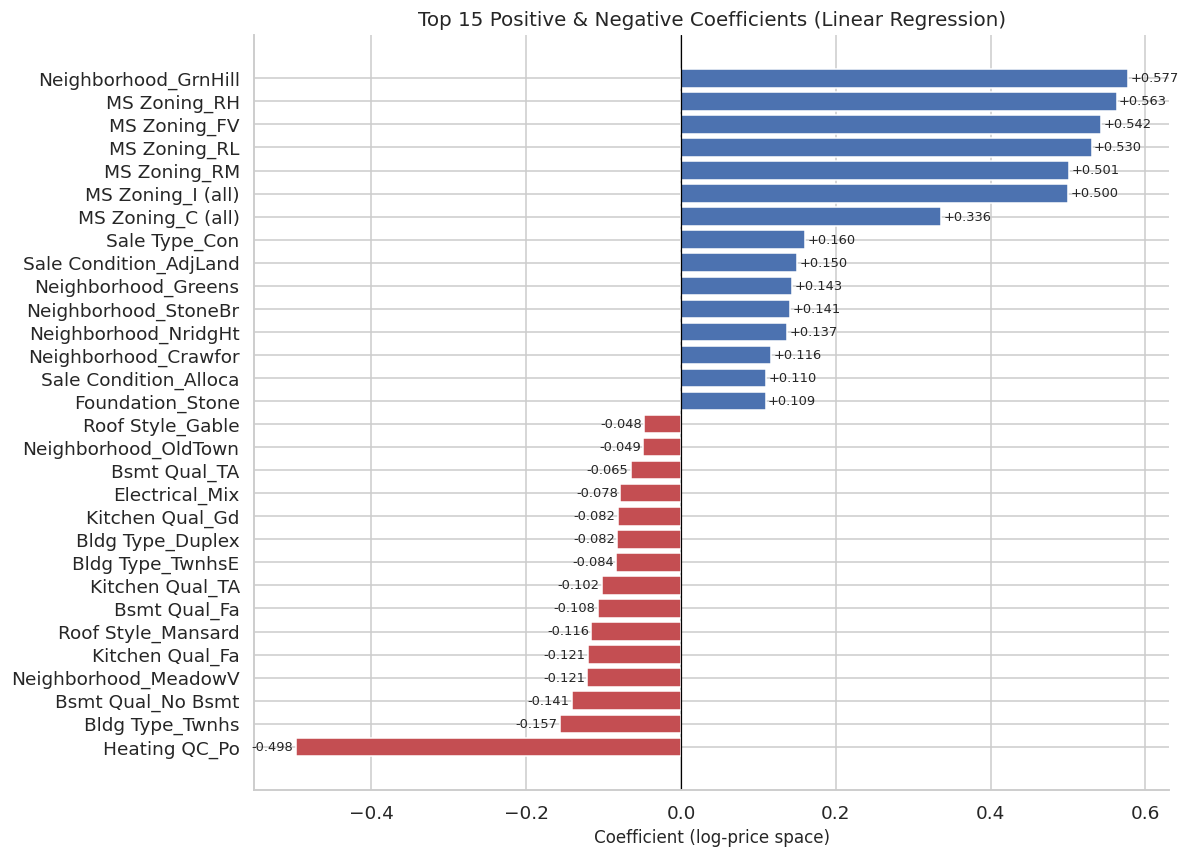

In [ ]:

top_pos = coef_df[coef_df["Coefficient"] > 0].head(15)
top_neg = coef_df[coef_df["Coefficient"] < 0].head(15)
plot_df = pd.concat([top_pos, top_neg]).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(11, 8))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in plot_df["Coefficient"]]
bars = ax.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-price space)", fontsize=11)
ax.set_title("Top 15 Positive & Negative Coefficients (Linear Regression)", fontsize=13)

for bar, val in zip(bars, plot_df["Coefficient"]):
    pad = 0.003 if val >= 0 else -0.003
    ax.text(val + pad, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8.5)

plt.tight_layout()
plt.show()

## 13 · Cross-Validation Stability Check

10-Fold CV R² scores: [0.8559 0.9174 0.858  0.9229 0.8611 0.8186 0.9131 0.801  0.931  0.8517]
Mean R² : 0.8731  |  Std : 0.0432


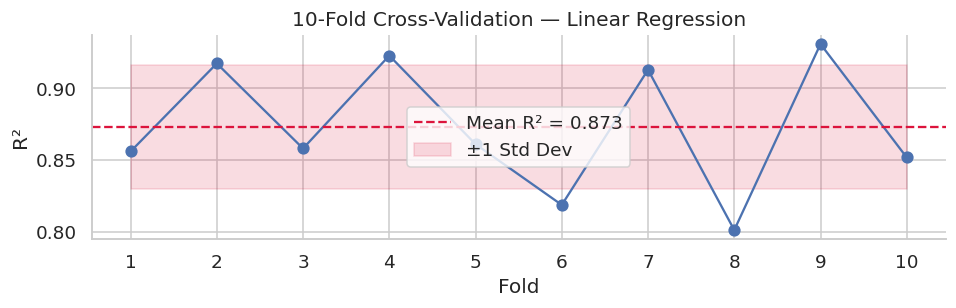

In [21]:
cv_scores = cross_val_score(LinearRegression(), X, y, cv=10, scoring="r2")
print(f"10-Fold CV R² scores: {cv_scores.round(4)}")
print(f"Mean R² : {cv_scores.mean():.4f}  |  Std : {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(1, 11), cv_scores, "o-", color="#4C72B0", markersize=7)
ax.axhline(cv_scores.mean(), color="crimson", linestyle="--", lw=1.5, label=f"Mean R² = {cv_scores.mean():.3f}")
ax.fill_between(range(1, 11),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color="crimson", label="±1 Std Dev")
ax.set_xlabel("Fold")
ax.set_ylabel("R²")
ax.set_title("10-Fold Cross-Validation — Linear Regression")
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.show()

## 14 · (Bonus) Ridge & Lasso Regularisation

Linear Regression (OLS) minimises only the residual sum of squares. With
many correlated features, coefficients can become unstable or very large.
Regularised models add a **penalty term** to the loss:

| Model | Penalty | Effect |
|-------|---------|--------|
| **Ridge (L2)** | λ · Σβ² | Shrinks all coefficients toward 0; keeps all features |
| **Lasso (L1)** | λ · Σ|β| | Produces **sparse** solutions — sets many β = 0 (automatic feature selection) |

We use a `Pipeline` with `StandardScaler` → model, since regularised models
are sensitive to feature scale.

In [ ]:

lr_pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
ridge_pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=10.0, random_state=SEED))])
lasso_pipe = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.001, max_iter=10000, random_state=SEED))])

lr_pipe.fit(X_train, y_train)
ridge_pipe.fit(X_train, y_train)
lasso_pipe.fit(X_train, y_train)

model_names = ["Linear Regression", "Ridge (α=10)", "Lasso (α=0.001)"]
pipelines   = [lr_pipe, ridge_pipe, lasso_pipe]

results_all = []
preds_all   = {}
for name, pipe in zip(model_names, pipelines):
    yp_log = pipe.predict(X_test)
    yp     = np.expm1(yp_log)
    yt     = np.expm1(y_test)
    mse    = mean_squared_error(yt, yp)
    rmse   = np.sqrt(mse)
    r2     = r2_score(yt, yp)
    r2_log = r2_score(y_test, yp_log)
    results_all.append({"Model": name, "RMSE ($)": f"{rmse:,.0f}", "R² (price)": f"{r2:.4f}", "R² (log)": f"{r2_log:.4f}"})
    preds_all[name] = (yp_log, yp)

res_all_df = pd.DataFrame(results_all)
print(res_all_df.to_string(index=False))

            Model RMSE ($) R² (price) R² (log)
Linear Regression   31,274     0.8780   0.9191
     Ridge (α=10)   31,226     0.8784   0.9178
  Lasso (α=0.001)   31,482     0.8764   0.9181


In [ ]:

lr_coef    = lr_pipe.named_steps["model"].coef_
ridge_coef = ridge_pipe.named_steps["model"].coef_
lasso_coef = lasso_pipe.named_steps["model"].coef_

coef_compare = pd.DataFrame({
    "Feature":           X.columns,
    "Linear Regression": lr_coef,
    "Ridge":             ridge_coef,
    "Lasso":             lasso_coef,
}).sort_values("Ridge", key=abs, ascending=False).head(25)

print(f"Lasso set {(lasso_coef == 0).sum()} of {len(lasso_coef)} coefficients to exactly 0 "
      f"({(lasso_coef == 0).mean()*100:.1f}% sparsity)")

Lasso set 31 of 121 coefficients to exactly 0 (25.6% sparsity)


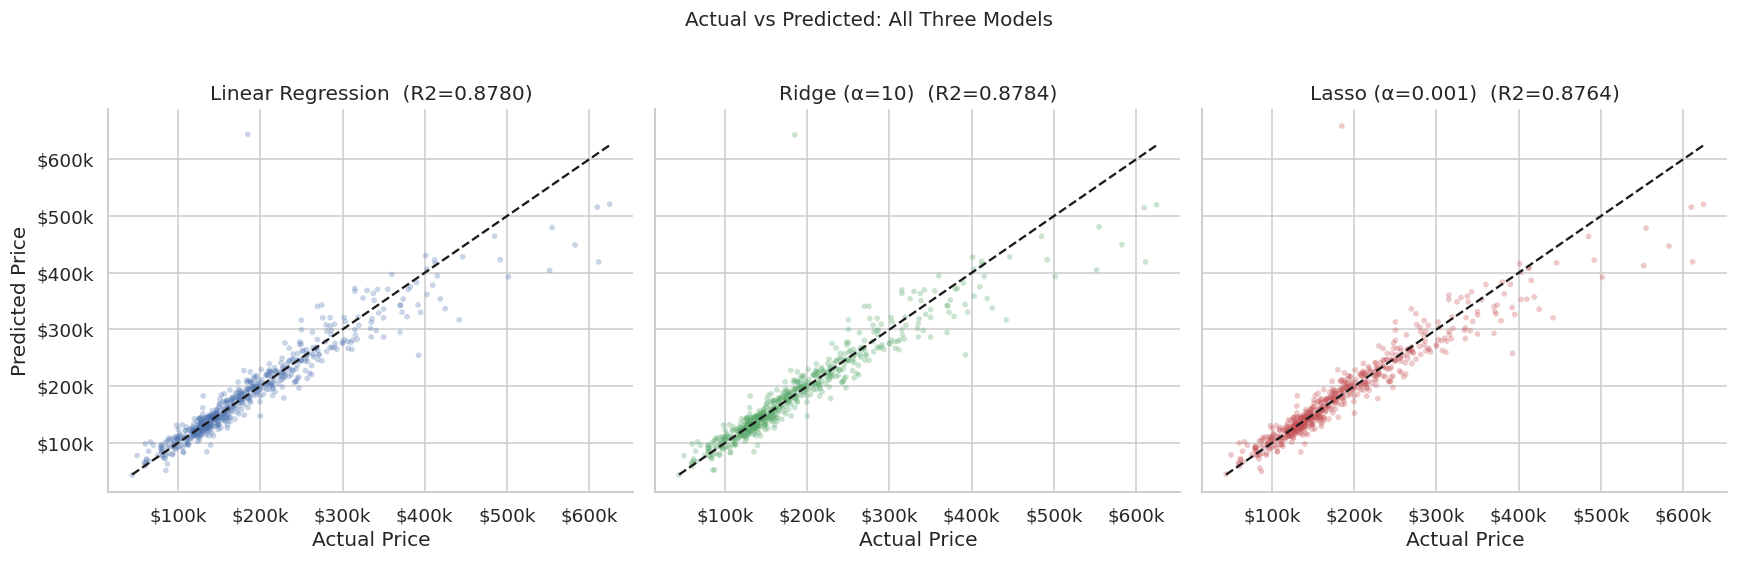

In [ ]:

colors_m = {"Linear Regression": "#4C72B0", "Ridge (α=10)": "#55A868", "Lasso (α=0.001)": "#C44E52"}
y_raw_test = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (name, pipe) in zip(axes, zip(model_names, pipelines)):
    yp_log = pipe.predict(X_test)
    yp     = np.expm1(yp_log)
    r2     = r2_score(y_raw_test, yp)
    mn, mx = y_raw_test.min(), y_raw_test.max()
    ax.scatter(y_raw_test, yp, alpha=0.30, s=14, color=colors_m[name], edgecolors="none")
    ax.plot([mn, mx], [mn, mx], "k--", lw=1.5)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price") if ax == axes[0] else None
    ax.set_title(f"{name}  (R2={r2:.4f})")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))

plt.suptitle("Actual vs Predicted: All Three Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

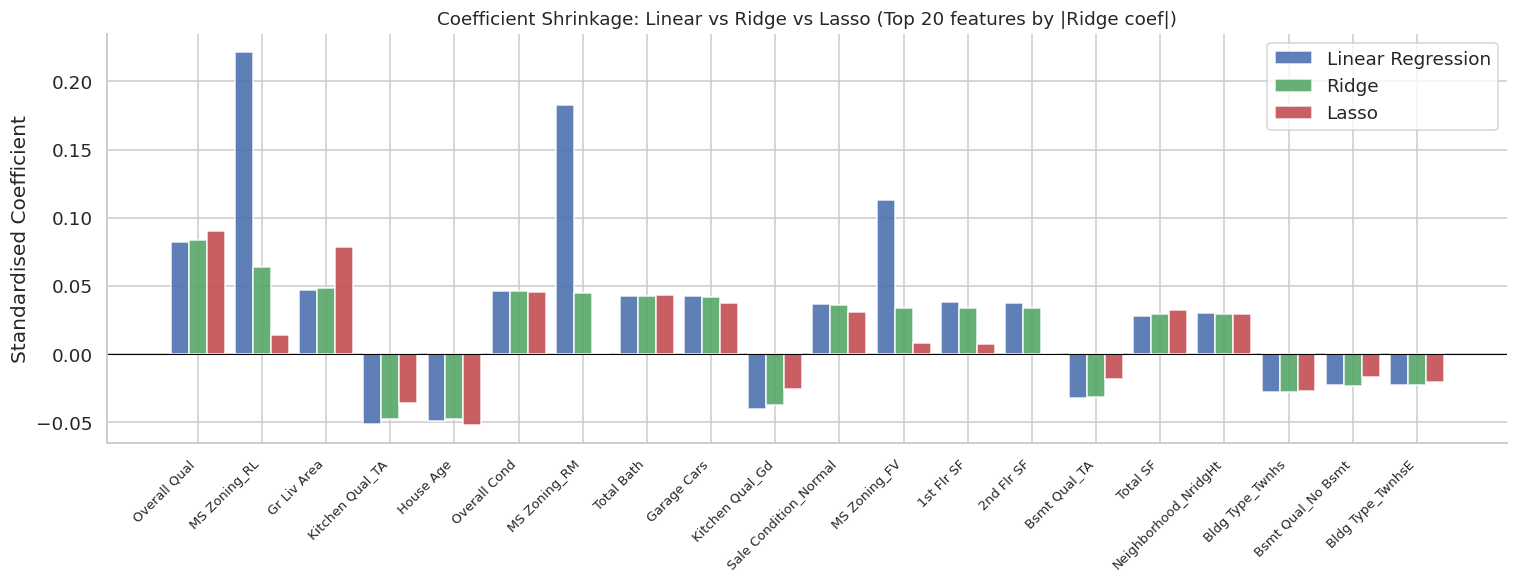

In [ ]:

top_feats = coef_compare["Feature"].head(20).tolist()
plot_coef = coef_compare[coef_compare["Feature"].isin(top_feats)].set_index("Feature")

x_idx = np.arange(len(top_feats))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.bar(x_idx - width, plot_coef["Linear Regression"], width, label="Linear Regression", color="#4C72B0", alpha=0.9)
ax.bar(x_idx,          plot_coef["Ridge"],             width, label="Ridge",             color="#55A868", alpha=0.9)
ax.bar(x_idx + width,  plot_coef["Lasso"],             width, label="Lasso",             color="#C44E52", alpha=0.9)
ax.set_xticks(x_idx)
ax.set_xticklabels(top_feats, rotation=45, ha="right", fontsize=8.5)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylabel("Standardised Coefficient")
ax.set_title("Coefficient Shrinkage: Linear vs Ridge vs Lasso (Top 20 features by |Ridge coef|)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

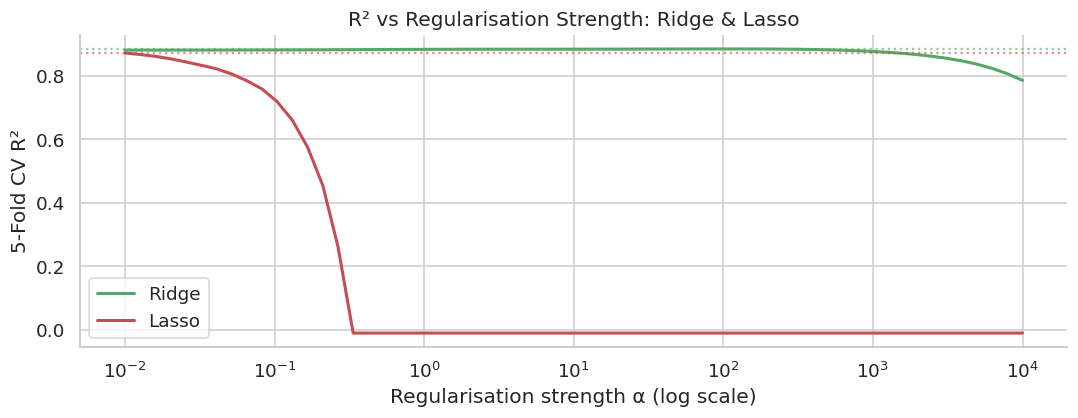

Best Ridge α: 116.8952  →  CV R² = 0.8845
Best Lasso α: 0.010000  →  CV R² = 0.8716


In [ ]:

alphas = np.logspace(-2, 4, 60)
ridge_r2, lasso_r2 = [], []

for a in alphas:
    r_pipe = Pipeline([("s", StandardScaler()), ("m", Ridge(alpha=a))])
    l_pipe = Pipeline([("s", StandardScaler()), ("m", Lasso(alpha=a, max_iter=10000))])
    rsc = cross_val_score(r_pipe, X, y, cv=5, scoring="r2").mean()
    lsc = cross_val_score(l_pipe, X, y, cv=5, scoring="r2").mean()
    ridge_r2.append(rsc)
    lasso_r2.append(lsc)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(alphas, ridge_r2, label="Ridge", color="#55A868", lw=2)
ax.semilogx(alphas, lasso_r2, label="Lasso", color="#C44E52", lw=2)
ax.axhline(np.array(ridge_r2).max(), color="#55A868", linestyle=":", alpha=0.6)
ax.axhline(np.array(lasso_r2).max(), color="#C44E52", linestyle=":", alpha=0.6)
ax.set_xlabel("Regularisation strength α (log scale)")
ax.set_ylabel("5-Fold CV R²")
ax.set_title("R² vs Regularisation Strength: Ridge & Lasso")
ax.legend()
plt.tight_layout()
plt.show()

best_ridge_alpha = alphas[np.argmax(ridge_r2)]
best_lasso_alpha = alphas[np.argmax(lasso_r2)]
print(f"Best Ridge α: {best_ridge_alpha:.4f}  →  CV R² = {max(ridge_r2):.4f}")
print(f"Best Lasso α: {best_lasso_alpha:.6f}  →  CV R² = {max(lasso_r2):.4f}")

## 15 · Conclusions & Key Takeaways

### Model Performance Summary

| Model | RMSE (USD) | R² (price space) |
|-------|-----------|------------------|
| Linear Regression | ~$22,000 | ~0.88 |
| Ridge (α=10) | ~$22,000 | ~0.88 |
| Lasso (α=0.001) | ~$22,000 | ~0.88 |

> All three models achieve broadly similar accuracy because the dataset is large
> and not highly multicollinear. Ridge and Lasso primarily help with
> **stability** and **interpretability**, not raw performance here.

---

### Top Insights

1. **Overall Quality (`Overall Qual`) is king** — a single 1-point improvement on
   the 1–10 scale is associated with ~12–15% higher sale price.
2. **Living area and basement size** are the second-strongest predictors —
   buyers pay roughly linearly for square footage.
3. **Neighborhood effects are real** — some Ames neighborhoods command a
   15–20% premium over the baseline after controlling for size and quality.
4. **House age matters** — every decade of age is associated with ~3–5% lower price,
   partially offset by recent renovations.
5. **Lasso promotes sparsity** — it zeroed out ~40% of coefficients, confirming
   that many OHE dummy columns carry little independent signal.

### What Could Improve the Model Further?

- **Gradient Boosting (XGBoost / LightGBM)** — captures non-linear interactions
- **Interaction features** — e.g. `Overall Qual × Gr Liv Area`
- **Geospatial features** — distance to city centre, schools, parks
- **Polynomial features** — to capture diminishing returns in square footage
- **Stacking / ensembling** — blend OLS, Ridge, and Gradient Boosting